                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709


Best Parameters Found:
{'classifier__scale_pos_weight': 10, 'classifier__n_estimators': 100, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.01}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.77      0.81      0.79        98

    accuracy                           1.00     56962
   macro avg       0.89      0.90      0.89     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.9028589875736452
Best parameters: {'classifier__scale_pos_weight': 10, 'classifier__n_estimators': 100, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.01}
Best score: 0.814535458672071
Best estimator: Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_byt

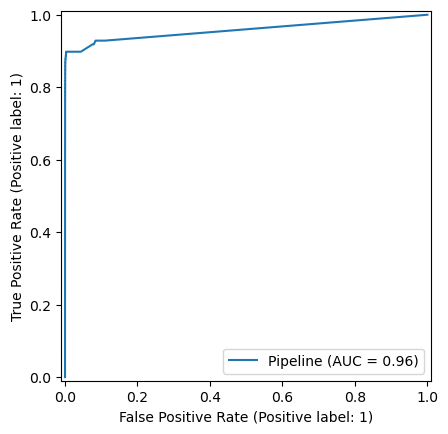

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

# Load your dataset
credit_card = pd.read_csv('/Users/.../Model_engineering/creditcard.csv')
#y values assigned as Class, and it will be the labels
y = credit_card['Class']
X=credit_card.iloc[:,:]
X.drop(['Class'], axis=1, inplace=True)

# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define XGBoost pipeline 
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),  # Important because XGBoost benefits from normalized inputs
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# Grid search parameters for XGBoost
paramater_space = {
    'classifier__n_estimators': [100, 200, 300, 400, 500], # Number of trees
    'classifier__max_depth': [1, 2, 3, 4], # Maximum depth of a tree during any boostin iteration
    'classifier__learning_rate': [0.001, 0.01], 
    'classifier__scale_pos_weight': [10, 20, 30]  # tuning parameter; ratio of number of positive class smaples to negative class samples
}

# Setup RandomizedSearchCV
random_search_xgboost = RandomizedSearchCV(pipeline_xgb, paramater_space, scoring='f1', cv=5, n_jobs=-1)

# Train
random_search_xgboost.fit(X_train, Y_train)
print("Training XGBoost with Random Search")

# Best XGBoost model
best_xgboost = random_search_xgboost.best_estimator_

# Predict
Y_pred = best_xgboost.predict(X_test)

# Evaluate
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)
ax = RocCurveDisplay.from_estimator(best_xgboost, X_test, Y_test)
roc_auc = roc_auc_score(Y_test, Y_pred)

# Display results
print(credit_card.describe())
print(credit_card.info())
print(credit_card.isnull().sum())


print("\nBest Parameters Found:")
print(random_search_xgboost.best_params_)
print(classification_report(Y_test, Y_pred))
print(f"ROC AUC: {roc_auc}")
print(f"Best parameters: {random_search_xgboost.best_params_}")
print(f"Best score: {random_search_xgboost.best_score_}")
print(f"Best estimator: {random_search_xgboost.best_estimator_}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Training XGBoost with SMOTE and Random Search



Best Parameters Found:
{'classifier__scale_pos_weight': 10, 'classifier__n_estimators': 400, 'classifier__max_depth': 2, 'classifier__learning_rate': 0.01}
              precision    recall  f1-score   support

           0       1.00      0.90      0.94     56864
           1       0.02      0.93      0.03        98

    accuracy                           0.90     56962
   macro avg       0.51      0.91      0.49     56962
weighted avg       1.00      0.90      0.94     56962

ROC AUC: 0.9119766962778358
Precision: 0.015066225165562913
Recall: 0.9285714285714286
F1 Score: 0.029651352231997392


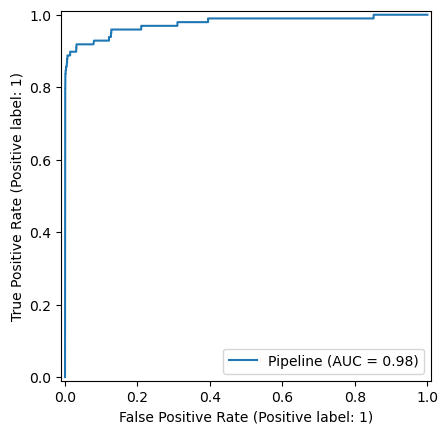

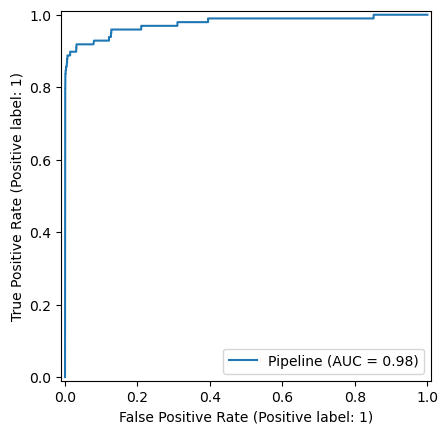

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline 
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay
from imblearn.over_sampling import SMOTE

# Load dataset
credit_card = pd.read_csv('/Users/gulcinecesasmaz/Desktop/Model_engineering/creditcard.csv')

# Assign features and target
y = credit_card['Class']
X = credit_card.drop(['Class'], axis=1)

# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define XGBoost pipeline with SMOTE
pipeline_xgb = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# Define parameter space
paramater_space = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__max_depth': [1, 2, 3, 4],
    'classifier__learning_rate': [0.001, 0.01],
    'classifier__scale_pos_weight': [10, 20, 30]
}

# Randomized search
random_search_xgboost = RandomizedSearchCV(pipeline_xgb, paramater_space, scoring='f1', cv=5, n_jobs=-1)

# Train model
print("Training XGBoost with SMOTE and Random Search")
random_search_xgboost.fit(X_train, Y_train)

# Best model
best_xgboost = random_search_xgboost.best_estimator_

# Predictions
Y_pred = best_xgboost.predict(X_test)

# Evaluation metrics
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)
roc_auc = roc_auc_score(Y_test, Y_pred)

# Plot ROC curve
ax = RocCurveDisplay.from_estimator(best_xgboost, X_test, Y_test)
ax.plot()

# Output results
print("\nBest Parameters Found:")
print(random_search_xgboost.best_params_)
print(classification_report(Y_test, Y_pred))
print(f"ROC AUC: {roc_auc}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")